In [17]:
import os
import random
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import pandas as pd
import json
import tqdm

import seaborn as sns
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
model_id="Qwen/Qwen2.5-0.5B-Instruct"

model=AutoModelForCausalLM.from_pretrained(model_id,trust_remote_code=True)
tokenizer=AutoTokenizer.from_pretrained(model_id,trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

In [ ]:
activations={}
# def make_hook(layer_idx):
#   def hook(module, input, output):
#         hidden = output[0]          # grab the tensor
#         last_token = hidden[:, -1, :]   # last token position
#         activations[layer_idx] = last_token.detach().cpu()
#   return hook

def get_response(model, tokenizer, prompt):
    messages=[
        {"role":"user", "content":prompt}
    ]
    # activations.clear()      # reset from previous call

    # hooks = []
    # for i, layer in enumerate(model.model.layers):
    #     h = layer.register_forward_hook(make_hook(i))
    #     hooks.append(h)

    text=tokenizer.apply_chat_template(messages,tokenize=False,add_generation_prompt=True,enable_thinking=False)
    inputs=tokenizer([text],return_tensors='pt',padding=True, truncation=True, max_length=128).to(model.device)
    # inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(model.device)
    with torch.no_grad():
        output = model(**inputs, output_hidden_states=True)
        hidden_states=output.hidden_states

    activations=torch.stack([h[:,-1,:].cpu() for h in hidden_states])
    return activations
    # for h in hooks:
    #     h.remove()

    # return hooks


## Caching Activations per batch

In [ ]:
import torch
from tqdm import tqdm

def get_activations_batch(model, tokenizer, prompts, max_length=128, token_position=-1,relative_position=None):
    texts = []

    for prompt in prompts:
        messages = [
            {"role": "user", "content": prompt}
        ]

        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False
        )

        texts.append(text)

   
    tokenizer.padding_side = "right"
   
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length
    ).to(model.device)

    with torch.no_grad():
        output = model(
            **inputs,
            output_hidden_states=True,
            use_cache=False
        )

    hidden_states = output.hidden_states
    batch_size = inputs["input_ids"].shape[0]
    batch_indices = torch.arange(batch_size, device=model.device)


    
    real_lengths = inputs["attention_mask"].sum(dim=1)

    if relative_position is not None:
        token_indices = ((real_lengths - 1) * relative_position).long()
    else:

      if token_position=="middle":
        token_indices=real_lengths//2
      elif token_position>=0:
        token_indices=torch.full((batch_size,), token_position,dtype=torch.long,device=model.device)
      else:
        token_indices=real_lengths+token_position
    print(token_indices)

    layer_activations = []

    for h in hidden_states:
        acts = h[batch_indices, token_indices, :]
        layer_activations.append(acts.cpu())

    activations = torch.stack(layer_activations, dim=0)
    activations = activations.permute(1, 0, 2)

    return activations

In [ ]:
def cache_all_activations(model, tokenizer, prompt_list, batch_size=8, max_length=128,token_position=-1, relative_position=None):

    all_activations = []

    for start in tqdm(range(0, len(prompt_list), batch_size)):
        end = start + batch_size
        batch_prompts = prompt_list[start:end]

        batch_acts = get_activations_batch(
            model=model,
            tokenizer=tokenizer,
            prompts=batch_prompts,
            max_length=max_length,
            token_position=token_position,
            relative_position=relative_position
        )

        all_activations.append(batch_acts)

    all_activations = torch.cat(all_activations, dim=0)

    return all_activations

In [7]:
with open("data/happiness.json", "r") as f:
    happy_data = json.load(f)

with open("data/sadness.json", "r") as f:
    sad_data = json.load(f)

### We choose 100 happy and sad prompts

In [8]:
happy_prompts=happy_data[0:100]
sad_prompts=sad_data[0:100]

## Getting the activations of the last token position across layers

In [ ]:
happy_activations_pos_last=cache_all_activations(model,tokenizer,happy_prompts, batch_size=10,token_position=-1)
sad_activations_pos_last=cache_all_activations(model,tokenizer,sad_prompts,batch_size=10,token_position=-1)

 10%|█         | 1/10 [00:21<03:11, 21.33s/it]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


 20%|██        | 2/10 [00:40<02:38, 19.85s/it]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


 30%|███       | 3/10 [01:06<02:40, 22.89s/it]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


 30%|███       | 3/10 [01:12<02:48, 24.07s/it]


KeyboardInterrupt: 

In [4]:
happy_activations_pos_last=torch.load( "data/happy_activations.pt")
sad_activations_pos_last=torch.load( "data/sad_activations.pt")

In [5]:
def get_training_data(happy_activations,sad_activations):
  all_activations=torch.cat([happy_activations,sad_activations],dim=0)
  labels = torch.tensor(
      [1] * happy_activations.shape[0] +
      [0] * sad_activations.shape[0]
  )
  X = all_activations.detach().cpu().float().numpy()
  y = labels.detach().cpu().numpy()

  indices = np.arange(len(y))

  train_idx, test_idx = train_test_split(
      indices,
      test_size=0.2,
      random_state=42,
      stratify=y
  )
  return X,y,train_idx, test_idx

## Function for tyraining a logistic regression model for every layer

In [9]:
def log_reg_across_layers(X,y,train_idx, test_idx):
  layer_results=[]
  for l in range(X.shape[1]):
    X_train = X[train_idx, l, :]
    X_test = X[test_idx, l, :]
    y_train = y[train_idx]
    y_test = y[test_idx]

    clf = make_pipeline(
          StandardScaler(),
          LogisticRegression(
              max_iter=2000,
              random_state=42
          )
      )

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    layer_results.append({
        "layer": l,
        "accuracy": acc,
        "f1": f1
    })

    #print(f"Layer {l:02d} | Accuracy: {acc:.3f} | F1: {f1:.3f}")
  return layer_results


In [10]:
def plot_log_reg_results(layer_results):
  results_df = pd.DataFrame(layer_results)
  plt.figure(figsize=(8, 5))

  sns.lineplot(
      data=results_df,
      x="layer",
      y="accuracy",
      marker="o",
      label="Accuracy"
  )

  plt.xlabel("Layer")
  plt.ylabel("Score")
  plt.title("Happy vs Sad Probe Performance by Layer")
  plt.ylim(0, 1.05)
  plt.grid(True)
  plt.legend()
  plt.show()

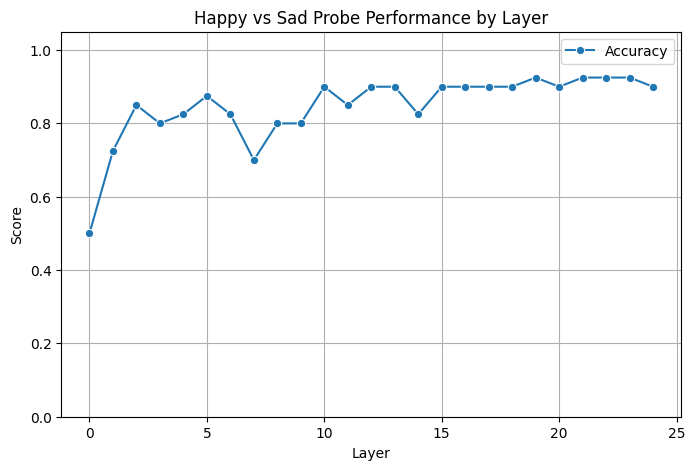

In [11]:
X,y,train_idx, test_idx=get_training_data(happy_activations_pos_last,sad_activations_pos_last)
layer_results=log_reg_across_layers(X,y,train_idx, test_idx)
plot_log_reg_results(layer_results)

## Probing for best token position across layers

In [ ]:
relative_positions = [0.0, 0.1, 0.25, 0.35, 0.5, 0.6, 0.75, 0.8, 0.9 1.0]

all_results = []

for rel_pos in relative_positions:
    print(f"Running relative_position={rel_pos}")

    happy_acts = cache_all_activations(
        model,
        tokenizer,
        happy_prompts,
        batch_size=10,
        relative_position=rel_pos
    )

    sad_acts = cache_all_activations(
        model,
        tokenizer,
        sad_prompts,
        batch_size=10,
        relative_position=rel_pos
    )

    X, y, train_idx, test_idx = get_training_data(
        happy_acts,
        sad_acts
    )

    layer_results = log_reg_across_layers(
        X,
        y,
        train_idx,
        test_idx
    )

    for r in layer_results:
        all_results.append({
            "relative_position": rel_pos,
            "layer": r["layer"],
            "accuracy": r["accuracy"],
            "f1": r["f1"]
        })

results_df = pd.DataFrame(all_results)

Running relative_position=0.0


NameError: name 'cache_all_activations' is not defined

In [14]:
results_df=pd.read_csv("data/probe_results_by_position.csv")

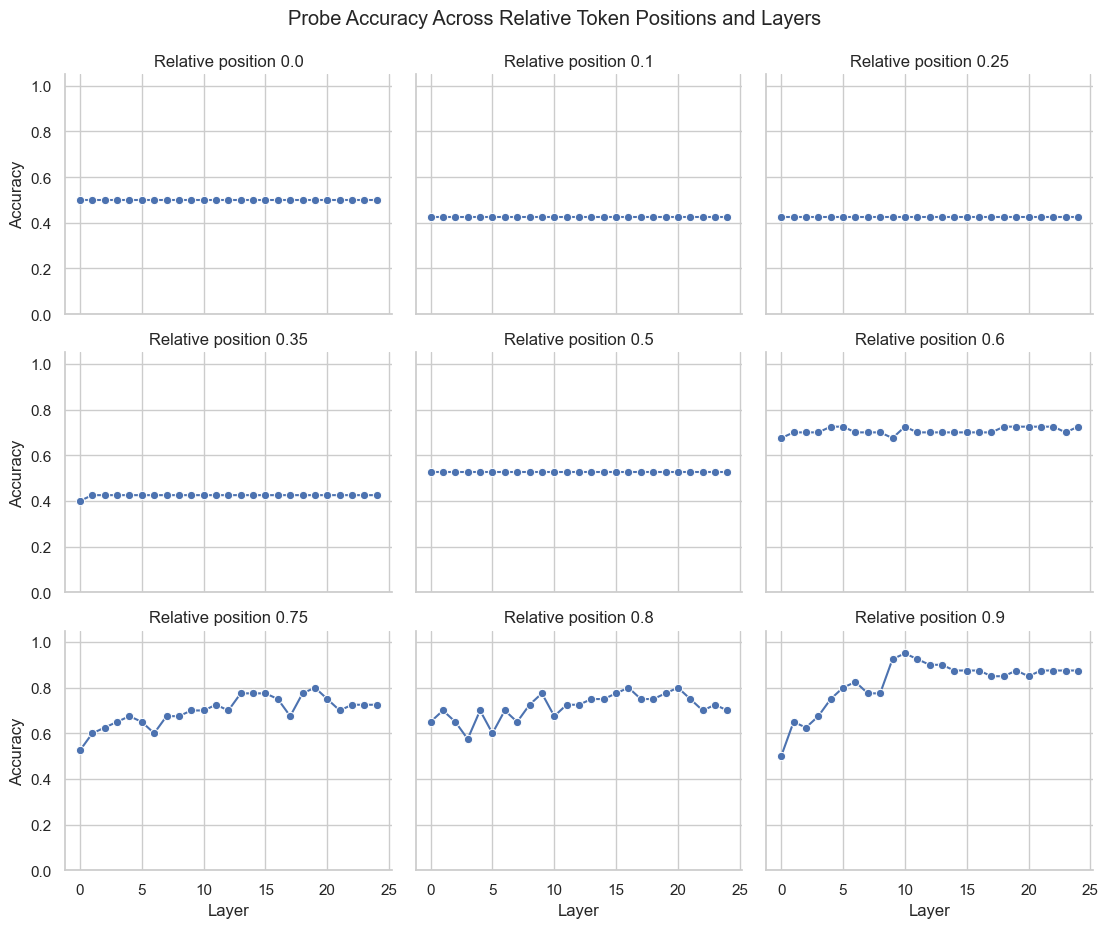

In [18]:
results_df = pd.read_csv("data/probe_results_by_position.csv")
results_df = results_df[~np.isclose(results_df["relative_position"], 1.0)].copy()

sns.set_theme(style="whitegrid")

g = sns.relplot(
    data=results_df,
    x="layer",
    y="accuracy",
    col="relative_position",
    col_wrap=3,
    kind="line",
    marker="o",
    height=3,
    aspect=1.25
)

g.set_axis_labels("Layer", "Accuracy")
g.set_titles("Relative position {col_name}")

for ax in g.axes.flat:
    ax.set_ylim(0, 1.05)

plt.suptitle("Probe Accuracy Across Relative Token Positions and Layers", y=1.03)
plt.show()

In [ ]:
results_df = pd.DataFrame(all_results)
results_df.to_csv("probe_results_by_position.csv", index=False)